In [1]:
%matplotlib widget

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from mpl_toolkits.mplot3d import Axes3D

plt.rc('legend',fontsize=6)
plt.rcParams["axes3d.mouserotationstyle"] = "azel"

In [4]:
FILENAME = "TUG2"
df = pd.read_csv(f"../data/opti_{FILENAME}.csv")

x = df['posX'].values
y = df['posY'].values
z = df['posZ'].values

interactive(children=(IntSlider(value=804, description='i', max=1608, min=1), Output()), _dom_classes=('widget…

<function __main__.plot_until(i)>

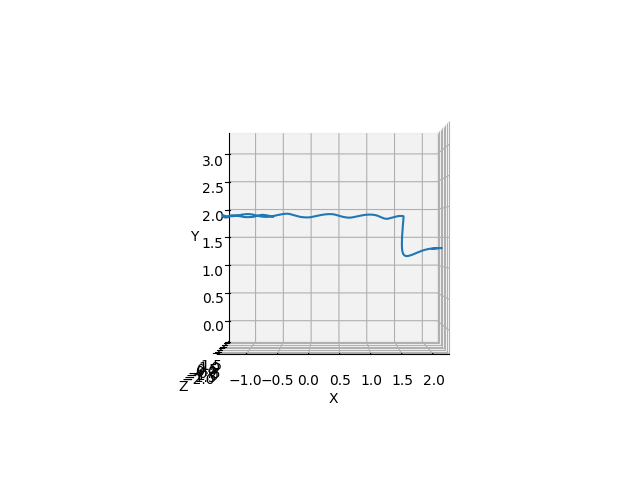

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=0, azim=-90)

# Axes scale evenly
max_range = np.array([
    x.max() - x.min(),
    y.max() - y.min(),
    z.max() - z.min()
]).max() / 2

mid_x = (x.max() + x.min()) * 0.5
mid_y = (y.max() + y.min()) * 0.5
mid_z = (z.max() + z.min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_zlim(mid_y - max_range, mid_y + max_range)
ax.set_ylim(mid_z - max_range, mid_z + max_range)
ax.set_box_aspect([1,1,1])

ax.set_xlabel("X")
ax.set_zlabel("Y")
ax.set_ylabel("Z")


line, = ax.plot([], [], [])

def plot_until(i):
    line.set_data(x[:i], z[:i])
    line.set_3d_properties(y[:i])
    fig.canvas.draw_idle()

interact(plot_until, i=(1, len(df)))